In [ ]:
!pip install --upgrade scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 31.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-image
    Found existing installation: scikit-image 0.25.2
    Uninstalling scikit-image-0.25.2:
      Successfully uninstalled scikit-image-0.25.2


In [ ]:
## Step 1: Import Libraries
## ----------------------------
import numpy as np
import pandas as pd
import cv2
import os
import matplotlib.pyplot as plt

from skimage.feature import local_binary_pattern
from scipy.stats import entropy as scipy_entropy, skew, kurtosis

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
import cv2
import numpy as np
from skimage.feature import local_binary_pattern
from scipy.stats import entropy as scipy_entropy, skew, kurtosis
import pywt  # wavelet transform

# ------------------------------
# Hit-or-Miss Feature
# ------------------------------
def hit_or_miss_feature(gray):
    _, binary = cv2.threshold(gray, 128, 1, cv2.THRESH_BINARY)
    kernels = [
        np.array([[1,1,1],[0,0,0],[0,0,0]], dtype=np.uint8),
        np.array([[1,0,0],[1,0,0],[1,0,0]], dtype=np.uint8),
        np.array([[1,0,0],[0,1,0],[0,0,1]], dtype=np.uint8),
        np.array([[0,0,1],[0,1,0],[1,0,0]], dtype=np.uint8)
    ]
    count = 0
    for k in kernels:
        hitmiss = cv2.morphologyEx(binary, cv2.MORPH_HITMISS, k)
        count += np.sum(hitmiss)
    return count

# ------------------------------
# Morphological Features
# ------------------------------
def morphological_features(gray):
    morph_feats = []
    kernel = np.ones((3,3), np.uint8)
    morphs = [
        cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel),
        cv2.morphologyEx(gray, cv2.MORPH_CLOSE, kernel),
        cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel),
        cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    ]
    for m in morphs:
        morph_feats.append(np.mean(m))
        morph_feats.append(np.std(m))
    return morph_feats

# ------------------------------
# Wavelet Features
# ------------------------------
def wavelet_features(gray):
    coeffs2 = pywt.dwt2(gray, 'haar')  # Haar wavelet
    cA, (cH, cV, cD) = coeffs2
    feats = [np.mean(cA), np.std(cA),
             np.mean(cH), np.std(cH),
             np.mean(cV), np.std(cV),
             np.mean(cD), np.std(cD)]
    return feats

# ------------------------------
# Full Feature Extraction
# ------------------------------
def extract_features(gray):
    features = []

    # 1- Laplacian Variance
    features.append(cv2.Laplacian(gray, cv2.CV_64F).var())

    # 2- FFT Mean
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    features.append(np.mean(np.abs(fshift)))

    # 3- Tenengrad (gradient magnitude)
    sobx = cv2.Sobel(gray, cv2.CV_64F, 1, 0)
    soby = cv2.Sobel(gray, cv2.CV_64F, 0, 1)
    grad_mag = np.sqrt(sobx**2 + soby**2)
    features.append(np.mean(grad_mag))
    features.append(np.var(grad_mag))

    # 4- Standard Deviation
    features.append(np.std(gray))

    # 5- Entropy
    hist,_ = np.histogram(gray, bins=256, range=(0,256))
    hist = hist / hist.sum()
    features.append(scipy_entropy(hist))

    # 6- Skewness
    features.append(skew(gray.flatten()))

    # 7- Kurtosis
    features.append(kurtosis(gray.flatten()))

    # 8- LBP (P=16, R=2, rotation-invariant)
    lbp = local_binary_pattern(gray, P=16, R=2, method="ror")
    hist_lbp,_ = np.histogram(lbp, bins=np.arange(0, 20), density=True)
    features.extend(hist_lbp)

    # 9- Hit-or-Miss
    features.append(hit_or_miss_feature(gray))

    # 10- Morphological features
    features.extend(morphological_features(gray))

    # 11- Wavelet features
    features.extend(wavelet_features(gray))

    return features

In [ ]:
## Step 3: Load Dataset & Extract Features
## ----------------------------
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kwentar/blur-dataset")
dataset_path= path
folders_with_labels = [
    ("sharp", 1),
    ("defocused_blurred", 0),
    ("motion_blurred", 0)
]

features = []
labels = []

for folder_name, label in folders_with_labels:
    folder_path = os.path.join(dataset_path, folder_name)
    for image_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, image_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        features_vec = extract_features(gray)
        features.append(features_vec)
        labels.append(label)

X = np.array(features)
y = np.array(labels)
print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Using Colab cache for faster access to the 'blur-dataset' dataset.


In [ ]:
# ==============================
# Step 1: Download KADID-10K
# ==============================

import kagglehub
import os
import pandas as pd
import cv2
import numpy as np

path_2 = kagglehub.dataset_download("srachejack/kadid10k")
dataset_path_2 = path_2

print("Dataset downloaded at:", dataset_path_2)
print("Contents:", os.listdir(dataset_path_2))


# ==============================
# Step 2: Read DMOS file
# ==============================

# تأكدي من اسم الملف حسب structure عندك
csv_path = os.path.join(dataset_path_2, "image_labeled_by_per_noise.csv")
df_2 = pd.read_csv(csv_path)

print(df_2.head())


# ==============================
# Step 3: Convert DMOS to Binary Label
# ==============================

"""
DMOS interpretation:
High DMOS → bad quality → Blur → label 0
Low DMOS → good quality → Sharp → label 1
"""

threshold_dmos = 3.0

df_2["label"] = df_2["dmos"].apply(lambda x: 0 if x > threshold_dmos else 1)

print("Label distribution:")
print(df_2["label"].value_counts())


# ==============================
# Step 4: Extract Features
# ==============================

features_2 = []
labels_2 = []

print("Starting feature extraction...")

for img_name, lbl in zip(df_2["image"], df_2["label"]):

    img_found = False

    # نبحث عن الصورة داخل كل مجلدات dataset
    for root, dirs, files in os.walk(dataset_path_2):

        img_path = os.path.join(root, img_name)

        if os.path.exists(img_path):

            img = cv2.imread(img_path)

            if img is not None:

                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

                # استخدام نفس الدالة المستخدمة في dataset الأول
                features_vec = extract_features(gray)

                features_2.append(features_vec)
                labels_2.append(lbl)

            img_found = True
            break

    if not img_found:
        print("Image not found:", img_name)


# ==============================
# Step 5: Convert to NumPy Arrays
# ==============================

X_2 = np.array(features_2)
y_2 = np.array(labels_2)

print("KADID Features shape:", X_2.shape)
print("KADID Labels shape:", y_2.shape)

100%|██████████| 2.86G/2.86G [00:47<00:00, 65.0MB/s]

Extracting files...


Dataset downloaded at: /root/.cache/kagglehub/datasets/srachejack/kadid10k/versions/1
Contents: ['image_labeled_by_per_noise.csv', 'images']
           image  dmos reference  noise
0  I01_01_01.png  4.57   I01.png      1
1  I01_01_02.png  4.33   I01.png      1
2  I01_01_03.png  2.67   I01.png      1
3  I01_01_04.png  1.67   I01.png      1
4  I01_01_05.png  1.10   I01.png      1
Label distribution:
label
1    5109
0    5016
Name: count, dtype: int64
Starting feature extraction...
KADID Features shape: (10125, 44)
KADID Labels shape: (10125,)


In [ ]:
X_all = np.concatenate([X, X_2], axis=0)
y_all = np.concatenate([y, y_2], axis=0)

print(X_all.shape)
print(y_all.shape)

(11175, 44)
(11175,)


In [ ]:
## ----------------------------
## Step 4: Train-Test Split & Scaling
## ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

In [ ]:
## ----------------------------
## Step 6: Train Model
## ----------------------------
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5615 - loss: 0.7801 - val_accuracy: 0.6743 - val_loss: 0.5992 - learning_rate: 0.0010
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6528 - loss: 0.6165 - val_accuracy: 0.7051 - val_loss: 0.5611 - learning_rate: 0.0010
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6844 - loss: 0.5833 - val_accuracy: 0.7060 - val_loss: 0.5574 - learning_rate: 0.0010
Epoch 4/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7031 - loss: 0.5595 - val_accuracy: 0.7221 - val_loss: 0.5311 - learning_rate: 0.0010
Epoch 5/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7070 - loss: 0.5543 - val_accuracy: 0.7315 - val_loss: 0.5267 - learning_rate: 0.0010
Epoch 6/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7039 - loss: 0.5490 - val_accuracy: 0.7378 - val_loss: 0.5187 - learning_rate: 0.0010
Epoch 7/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7185 - loss: 0.5328 - 

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.90      0.81      1143
           1       0.87      0.65      0.74      1092

    accuracy                           0.78      2235
   macro avg       0.80      0.78      0.78      2235
weighted avg       0.80      0.78      0.78      2235



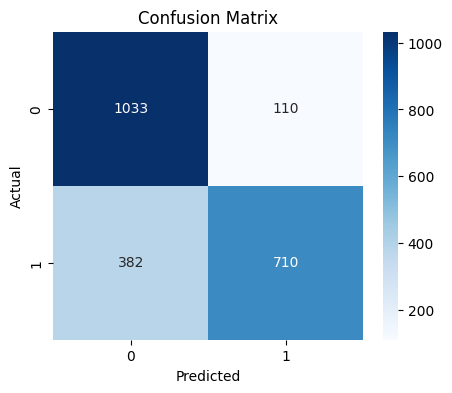

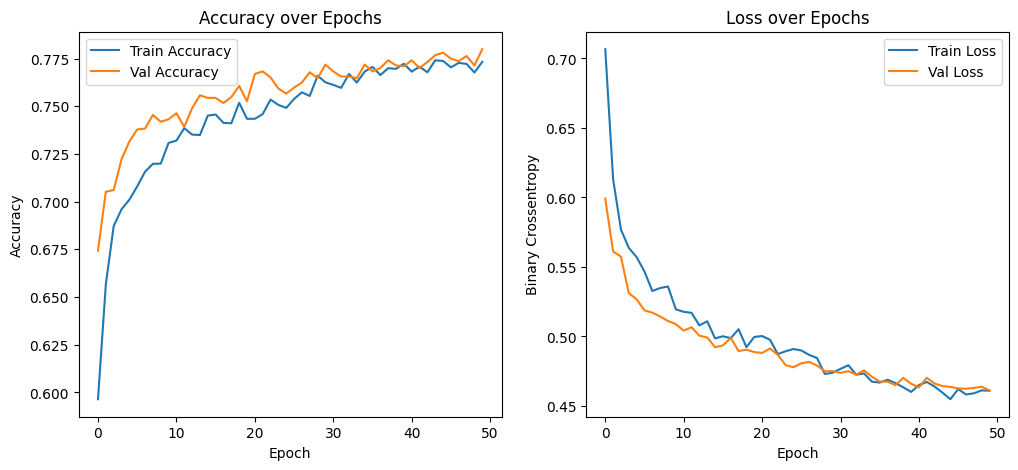

Final Train Accuracy: 0.7732661962509155
Final Validation Accuracy: 0.7798658013343811


In [ ]:
## ----------------------------
## Step 7: Evaluate Model
## ----------------------------
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.show()

print("Final Train Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

In [ ]:
# Save trained model
model.save("blur_mlp_model.h5")

print("Model saved successfully!")

In [ ]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Scaler saved successfully!")

In [ ]:
from google.colab import files
files.download("blur_mlp_model.h5")
files.download("scaler.pkl")